In [1]:
# pip install glob2
from PIL import Image
import glob

all_images = []
all_labels = []
img_size = (96, 96)
for f in glob.glob('c:\\data\\foods\\**\\*.jpg', recursive=True):
    arr = f.split('\\')
    img = Image.open(f)
    img_resize = img.resize((img_size[0], img_size[1]))
    all_images.append(img_resize)
    label = 0
    if arr[4] == 'Chicken':
        label = 0
    elif arr[4] == 'Dolsot':
        label = 1
    elif arr[4] == 'Jeyug':
        label = 2
    elif arr[4] == 'Kimchi':
        label = 3
    elif arr[4] == 'Samgyeob':
        label = 4
    elif arr[4] == 'Soybean':
        label = 5
    all_labels.append(label)

In [2]:
###############################
import numpy as np

#CNN형식에 맞게 2차원 ==> 4차원으로 변환
X = np.empty((1, img_size[0], img_size[1], 3))
for img in all_images:
    X = np.vstack((X, np.array(img).reshape(1, img_size[0], img_size[1], 3)))

X.shape

(239, 96, 96, 3)

In [3]:
###############################
X = np.delete(X, (0), axis=0)

In [4]:
###############################
X.shape

(238, 96, 96, 3)

In [5]:
###############################
y = np.array(all_labels)
y[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

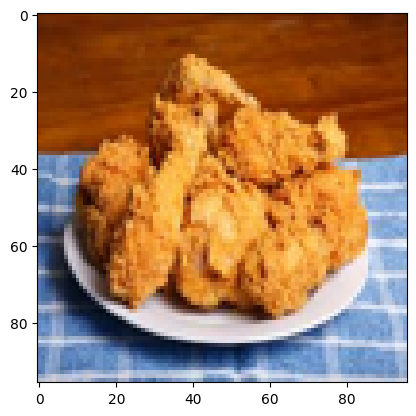

In [6]:
###############################
import matplotlib.pyplot as plt

plt.imshow(all_images[0])
plt.show()

In [7]:
###############################
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, shuffle=True, random_state=0)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((190, 96, 96, 3), (48, 96, 96, 3), (190,), (48,))

In [8]:
###############################
import pandas as pd

pd.DataFrame(y_train).value_counts()

0
0    40
1    32
3    32
5    32
2    30
4    24
Name: count, dtype: int64

In [10]:
###############################
X_train = X_train.reshape(-1, img_size[0] * img_size[1] * 3)
X_test = X_test.reshape(-1, img_size[0] * img_size[1] * 3)

In [11]:
###############################
X_train = X_train / 255.
X_test = X_test / 255.

In [12]:
###############################
X_train = X_train.reshape(-1, img_size[0], img_size[1], 3)
X_test = X_test.reshape(-1, img_size[0], img_size[1], 3)

In [13]:
###############################
y_train[:10]

array([3, 5, 1, 4, 3, 1, 4, 2, 4, 3])

In [14]:
###############################
from tensorflow.keras import utils

y_train_backup = y_train
y_test_backup = y_test
y_train = utils.to_categorical(y_train, 6)
y_test = utils.to_categorical(y_test, 6)

In [15]:
###############################
y_train[:5]

array([[0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0., 0.]])

In [16]:
###############################
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

model = Sequential()
model.add(Conv2D(64, (3, 3), padding="same", input_shape=X_train.shape[1:], activation='tanh'))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(32, (3, 3), activation="tanh"))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(16, (3, 3), activation="tanh"))
model.add(Flatten())
model.add(Dense(64, activation="relu"))
model.add(Dense(32, activation="relu"))
model.add(Dense(6, activation="softmax"))
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

C:\python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 46, 46, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7056)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       451,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 478,806 (1.83 MB)

 Trainable params: 478,806 (1.83 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
###############################
from keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint("c:/data/models/food_best.keras", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
hist = model.fit(X_train, y_train, batch_size=32, validation_split=0.2, epochs=100, callbacks=[checkpoint])

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.2536 - loss: 1.8189
Epoch 1: val_accuracy improved from None to 0.34211, saving model to c:/data/models/food_best.keras

Epoch 1: finished saving model to c:/data/models/food_best.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - accuracy: 0.2500 - loss: 1.8085 - val_accuracy: 0.3421 - val_loss: 1.6927
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.2701 - loss: 1.6649
Epoch 2: val_accuracy improved from 0.34211 to 0.47368, saving model to c:/data/models/food_best.keras

Epoch 2: finished saving model to c:/data/models/food_best.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.2829 - loss: 1.6450 - val_accuracy: 0.4737 - val_loss: 1.4787
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4139 - loss: 1.4131
Epoch 3: val_accuracy did not improve from 0.47368
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.4079 - loss: 1.3658 - val_accuracy: 0.3421 - val_loss: 1.3939
Epoch 4/100
5/5 ━━

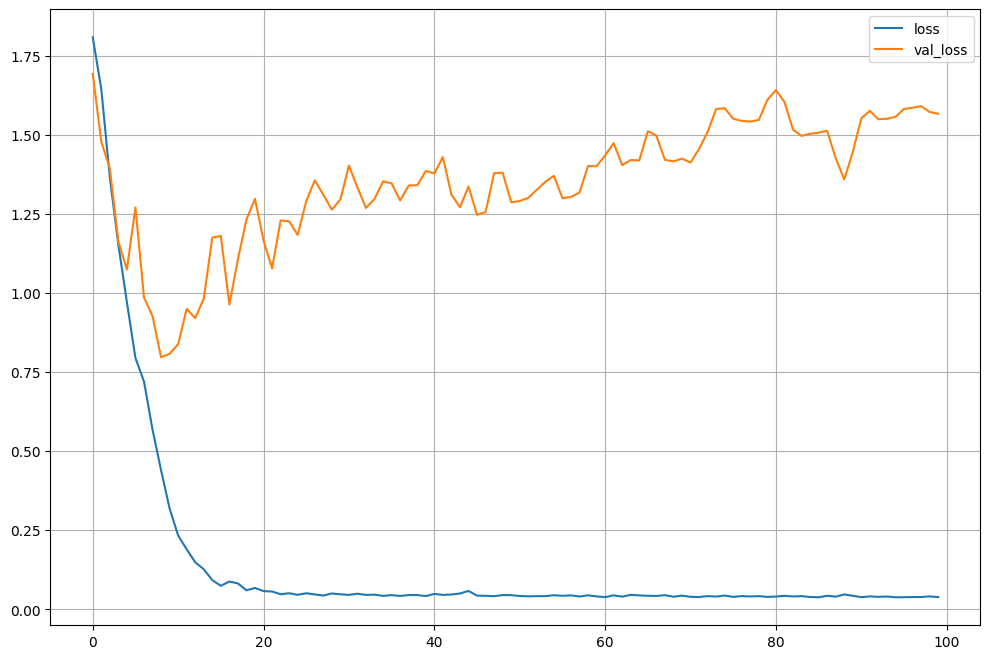

In [18]:
###############################
plt.figure(figsize=(12, 8))
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.grid()
plt.show()

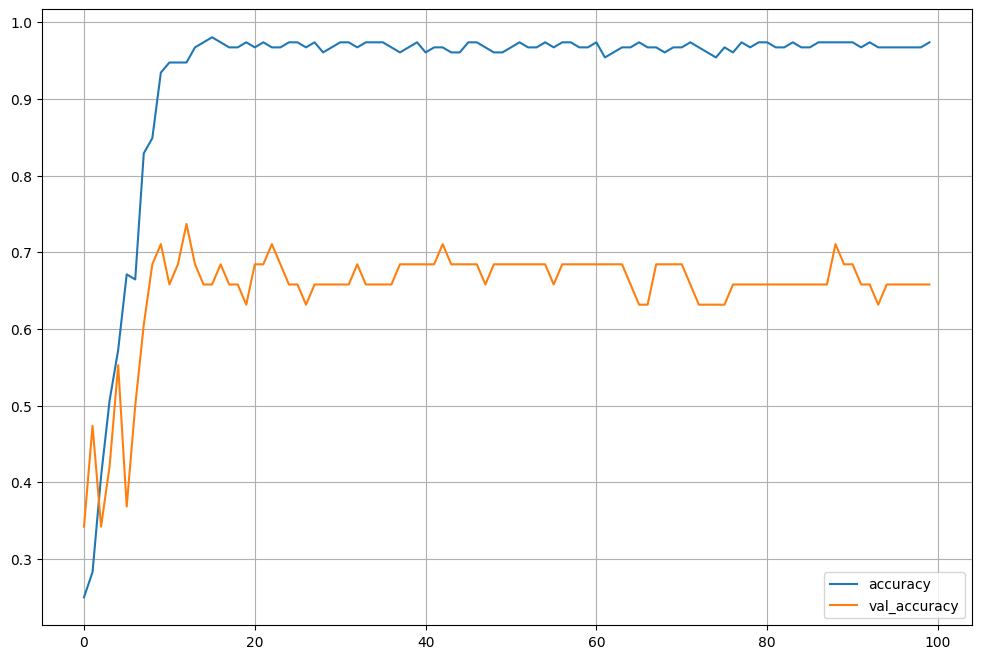

In [19]:
###############################
plt.figure(figsize=(12, 8))
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.legend(['accuracy', 'val_accuracy'])
plt.grid()
plt.show()

In [20]:
###############################
from tensorflow.keras.models import load_model

model = load_model('c:/data/models/food_best.keras')
scores = model.evaluate(X_train, y_train, verbose=1)
print(scores)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1] * 100))  #학습용

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9211 - loss: 0.2749
[0.27486589550971985, 0.9210526347160339]
compile_metrics: 92.11%


In [21]:
###############################
scores = model.evaluate(X_test, y_test, verbose=1)
print(scores)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1] * 100))  #검증용

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7292 - loss: 0.7054
[0.7054007053375244, 0.7291666865348816]
compile_metrics: 72.92%


In [22]:
###############################
pred = model.predict(X_test)
np.argmax(pred, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


array([3, 1, 2, 0, 0, 4, 1, 2, 0, 1, 1, 3, 4, 3, 4, 2, 2, 3, 0, 0, 3, 5,
       3, 1, 5, 0, 1, 1, 0, 5, 1, 3, 3, 1, 5, 4, 4, 0, 2, 2, 1, 4, 2, 0,
       0, 5, 3, 3])

In [24]:
###############################
from sklearn.metrics import classification_report

print(classification_report(y_test_backup, np.argmax(pred, axis=1)))

              precision    recall  f1-score   support

           0       0.70      0.70      0.70        10
           1       0.70      0.88      0.78         8
           2       0.86      0.75      0.80         8
           3       0.70      0.88      0.78         8
           4       0.67      0.67      0.67         6
           5       0.80      0.50      0.62         8

    accuracy                           0.73        48
   macro avg       0.74      0.73      0.72        48
weighted avg       0.74      0.73      0.72        48

